# 03 Train SVM (RBF) for Chlorophyll-a

This notebook trains Support Vector Machine (SVM) models
for Chlorophyll-a prediction using lag-based time series features.

Key characteristics:
- Time-based train/test split
- Lag feature engineering
- Feature scaling
- Restricted grid search
- Final model training for deployment


Cell 2: Import Libraries

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import ParameterGrid

import joblib

plt.rcParams["figure.figsize"] = (10, 4)


Cell 3: Paths

In [11]:
DATA_DIR = "../data_prepared"
MODEL_DIR = "../models_svm"
RESULT_DIR = "../results_svm"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)


Cell 4: Create Lag Features (Core)

In [12]:
def create_lag_features(series, lag=6):
    X, y = [], []
    for i in range(lag, len(series)):
        X.append(series[i-lag:i])
        y.append(series[i])
    return np.array(X), np.array(y)


Cell 5: Time-based Train/Test Split

In [13]:
def train_test_split_ts(X, y, train_ratio=0.8):
    split = int(len(X) * train_ratio)
    return X[:split], X[split:], y[:split], y[split:]


Cell 6: Restricted Grid Search for SVM

In [14]:
def svm_grid_search(X_train, y_train, X_val, y_val):
    param_grid = {
        "C": [1, 10, 100],
        "gamma": ["scale", 0.1, 0.01],
        "kernel": ["rbf"]
    }

    best_rmse = np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        model = SVR(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    return best_params, best_rmse


Cell 7: Loop Training + Evaluation (All Stations)

In [15]:
summary = []

for file in os.listdir(DATA_DIR):
    if not file.endswith("_prepared.csv"):
        continue

    station = file.split("_")[0]
    print(f"\n🔹 Training SVM for station: {station}")

    df = pd.read_csv(
        os.path.join(DATA_DIR, file),
        index_col="Date",
        parse_dates=True
    )

    # -------------------------
    # 1) Outlier handling
    # -------------------------
    chl_raw = df["Chlorophyll_a"].values

    if station in ["PN01", "SK01", "TP011"]:
        q_low, q_high = np.percentile(chl_raw, [5, 95])
        chl = np.clip(chl_raw, q_low, q_high)
    else:
        chl = chl_raw

    # -------------------------
    # 2) Adaptive lag
    # -------------------------
    if station in ["PN01", "SK01", "TP011"]:
        lag = 3
    else:
        lag = 6

    X, y = create_lag_features(chl, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split_ts(X, y)

    # -------------------------
    # 3) Scaling
    # -------------------------
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

    # -------------------------
    # 4) Grid search
    # -------------------------
    best_params, _ = svm_grid_search(
        X_train_scaled, y_train_scaled,
        X_test_scaled, y_test_scaled
    )

    # -------------------------
    # 5) Evaluation
    # -------------------------
    model = SVR(**best_params)
    model.fit(X_train_scaled, y_train_scaled)

    preds_scaled = model.predict(X_test_scaled)
    preds = scaler_y.inverse_transform(
        preds_scaled.reshape(-1, 1)
    ).ravel()

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    # -------------------------
    # 6) Final training (FULL data)
    # -------------------------
    X_full_scaled = scaler_X.fit_transform(X)
    y_full_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    final_model = SVR(**best_params)
    final_model.fit(X_full_scaled, y_full_scaled)

    # -------------------------
    # 7) Save model
    # -------------------------
    joblib.dump(
        {
            "model": final_model,
            "scaler_X": scaler_X,
            "scaler_y": scaler_y,
            "lag": lag
        },
        f"{MODEL_DIR}/{station}_svm_chlorophyll.pkl"
    )

    summary.append([
        station,
        best_params["C"],
        best_params["gamma"],
        rmse,
        mae
    ])



🔹 Training SVM for station: CP01

🔹 Training SVM for station: LS01

🔹 Training SVM for station: LS03

🔹 Training SVM for station: PN01

🔹 Training SVM for station: SK01

🔹 Training SVM for station: SK06

🔹 Training SVM for station: TP011

🔹 Training SVM for station: TP01

🔹 Training SVM for station: TP04


Cell 8: Save & Display Results

In [16]:
summary_df = pd.DataFrame(
    summary,
    columns=["Station", "C", "Gamma", "RMSE", "MAE"]
)

summary_df.to_csv(f"{RESULT_DIR}/svm_chlorophyll_evaluation.csv", index=False)
summary_df


,Station,C,Gamma,RMSE,MAE
0,CP01,1,0.01,1.502458,1.259461
1,LS01,1,0.01,1.908130,1.430415
2,LS03,1,0.1,1.488920,1.289903
3,PN01,1,0.1,4.151077,2.945810
4,SK01,1,0.01,8.763108,6.676341
5,SK06,100,0.01,1.739669,1.522382
6,TP011,10,0.01,3.202415,2.427261
7,TP01,1,scale,1.570490,1.379878
8,TP04,1,0.01,1.942516,1.626380


Cell 9: Plot Example (1 Station)

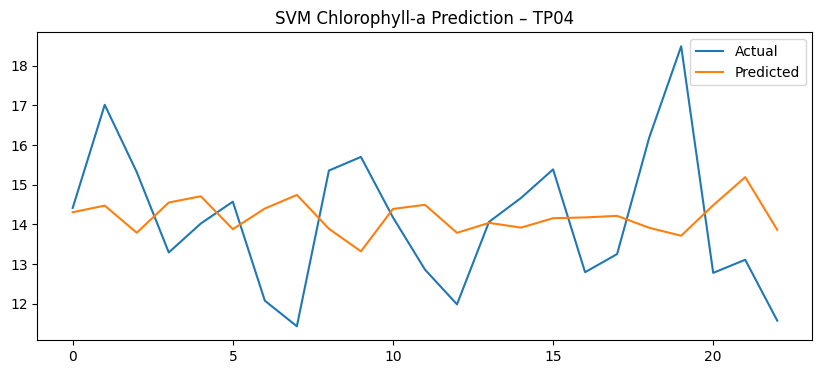

In [17]:
plt.figure()
plt.plot(y_test, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title(f"SVM Chlorophyll-a Prediction – {station}")
plt.show()


## Conclusion

- SVM with RBF kernel was successfully trained for Chlorophyll-a
- Time-based train/test split was applied
- Lag features captured temporal dependency
- Model performance was evaluated using RMSE and MAE
- Final models were trained using full datasets and saved for deployment
